# 데이터 점검 결과 요약

- 데이터 크기: 2000행 × 13열
- 결측값 개수: `이탈일`(1668개)
- 전처리 방향
  - `가입일`과 `이탈일`은 월별 이탈률 계산을 위해 날짜형으로 변환합니다.
  - `이탈여부`는 이탈률 계산을 위해 이진 플래그로 변환합니다.
  - 월별 분석을 위해 `가입월`과 `이탈월`을 생성합니다.
  - 교차분석을 위해 `나이`를 연령대 범주로 변환합니다.
  - `이탈여부`와 `이탈일`의 정합성을 점검합니다.
  - 수치형 변수의 범위와 이상치를 점검한 뒤 전처리 완료 데이터를 저장합니다.


### 0단계. 실습 데이터 준비

- 지시: Google Drive를 마운트하고, 실습 데이터 파일이 있는 폴더로 작업 경로를 변경하는 코드를 작성하세요.
- 이유: Google Colab에서 Google Drive에 저장된 실습 파일을 파일명만으로 읽기 위함입니다.
- 주의: 만약 로컬 컴퓨터에서 Jupyter Notebook을 실행하고 있다면, 이 단계를 생략하세요.

In [1]:
# Google Drive를 마운트합니다.
from google.colab import drive

drive.mount(mountpoint='/content/drive')

Mounted at /content/drive


In [2]:
# 실습 데이터 파일이 있는 폴더로 작업 경로를 변경합니다.
import os

os.chdir(path='/content/drive/MyDrive/workspace')

In [3]:
# 현재 작업 경로를 확인합니다.
os.getcwd()

'/content/drive/MyDrive/workspace'

### 1단계. 원본 데이터 불러오기 및 초기 점검

- 지시: customer_churn.csv 파일을 읽어 데이터프레임 df를 생성하고, df.head(), df.info(), df.isna().sum() 결과를 각각 별도의 셀에서 출력하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 분석 전에 데이터 구조, 자료형, 결측 상태를 빠르게 확인하기 위함입니다.

In [4]:
# 이 셀은 pandas를 불러옵니다.
import pandas as pd

In [5]:
# 이 셀은 customer_churn.csv 파일을 읽어 데이터프레임 df를 생성합니다.
df = pd.read_csv(filepath_or_buffer='customer_churn.csv')

In [6]:
# 이 셀은 데이터프레임의 앞부분 5행을 확인합니다.
df.head()

,고객ID,성별,나이,가입채널,요금제,가입일,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패,이탈여부,이탈일
0,C1000,여,26,오프라인매장,스탠다드,2024-11-07,19,3,9.9,1,1,Y,2026-04-10
1,C1001,남,49,제휴이벤트,베이직,2025-06-07,11,18,9.7,1,0,N,NaN
2,C1002,여,24,오프라인매장,스탠다드,2026-01-16,4,18,28.3,0,0,N,NaN
3,C1003,여,35,지인추천,프리미엄,2024-07-23,22,4,3.8,1,0,Y,2024-12-26
4,C1004,남,31,소셜미디어,베이직,2024-07-14,22,13,6.7,2,0,N,NaN


In [7]:
# 이 셀은 데이터프레임의 구조와 자료형을 확인합니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   고객ID        2000 non-null   object 
 1   성별          2000 non-null   object 
 2   나이          2000 non-null   int64  
 3   가입채널        2000 non-null   object 
 4   요금제         2000 non-null   object 
 5   가입일         2000 non-null   object 
 6   가입경과월       2000 non-null   int64  
 7   최근30일_로그인수  2000 non-null   int64  
 8   월평균사용시간     2000 non-null   float64
 9   고객센터문의수     2000 non-null   int64  
 10  최근3개월_결제실패  2000 non-null   int64  
 11  이탈여부        2000 non-null   object 
 12  이탈일         332 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.3+ KB


In [8]:
# 이 셀은 열별 결측값 개수를 확인합니다.
df.isna().sum()

,0
고객ID,0
성별,0
나이,0
가입채널,0
요금제,0
가입일,0
가입경과월,0
최근30일_로그인수,0
월평균사용시간,0
고객센터문의수,0


### 2단계. 날짜 변수와 이탈 플래그 변환

- 지시: df에서 `가입일`과 `이탈일`을 날짜형으로 변환하고, `이탈여부`가 Y이면 1이고 N이면 0인 `이탈플래그` 변수를 생성한 뒤 df_clean에 저장하세요.
- 이유: 월별 이탈률과 집단별 이탈률을 일관된 기준으로 계산하기 위함입니다.

In [9]:
# 이 셀은 가입일과 이탈일을 날짜형으로 변환하고,
# 이탈여부를 기준으로 이탈플래그 변수를 생성한 뒤 df_clean에 저장합니다.

df_clean = df.copy()

df_clean['가입일'] = pd.to_datetime(arg=df_clean['가입일'])
df_clean['이탈일'] = pd.to_datetime(arg=df_clean['이탈일'])

df_clean['이탈플래그'] = df_clean['이탈여부'].map({
    'Y': 1,
    'N': 0
})

### 3단계. 이탈 정보 정합성 점검

- 지시: df_clean에서 `이탈여부`와 `이탈일`의 조합별 고객 수를 집계하고, 이탈 고객의 `이탈일` 누락 여부와 유지 고객의 `이탈일` 존재 여부를 각각 별도의 셀에서 출력하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 이탈률 계산에 사용하는 핵심 라벨과 날짜 정보가 서로 모순되지 않는지 확인하기 위함입니다.

In [10]:
# 이 셀은 이탈여부와 이탈일의 조합별 고객 수를 집계합니다.
df_clean.groupby(
    by=['이탈여부', '이탈일'],
    dropna=False
).size()

이탈여부  이탈일       
N     NaT           1668
Y     2024-12-08       1
      2024-12-18       2
      2024-12-26       1
      2025-01-10       2
                    ... 
      2026-05-21       3
      2026-05-22       1
      2026-05-23       1
      2026-05-24       1
      2026-05-26       1
Length: 174, dtype: int64

In [11]:
# 이 셀은 이탈 고객 중 이탈일이 누락된 고객 수를 확인합니다.
df_clean.loc[
    df_clean['이탈여부'].eq(other='Y'),
    '이탈일'
].isna().sum()

np.int64(0)

In [12]:
# 이 셀은 유지 고객 중 이탈일이 존재하는 고객 수를 확인합니다.
df_clean.loc[
    df_clean['이탈여부'].eq(other='N'),
    '이탈일'
].notna().sum()

np.int64(0)

### 4단계. 월 변수와 연령대 변수 생성

- 지시: df_clean에서 `가입일` 기준 `가입월`, `이탈일` 기준 `이탈월`, `나이` 기준 10세 단위 `연령대` 변수를 생성한 뒤 df_clean에 반영하세요.
- 이유: 월별 이탈률과 연령대별 교차분석에 필요한 분석 단위를 만들기 위함입니다.

In [13]:
# 이 셀은 가입월, 이탈월, 10세 단위 연령대 변수를 생성해 df_clean에 반영합니다.
df_clean['가입월'] = df_clean['가입일'].dt.to_period(freq='M')
df_clean['이탈월'] = df_clean['이탈일'].dt.to_period(freq='M')

df_clean['연령대'] = (df_clean['나이'] // 10 * 10).astype(str) + '대'

### 5단계. 수치형 변수 범위와 이상치 점검

- 지시: df_clean의 `나이`, `가입경과월`, `최근30일_로그인수`, `월평균사용시간`, `고객센터문의수`, `최근3개월_결제실패`에 대해 기본 통계량과 이상치 후보 개수를 각각 별도의 셀에서 출력하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 고이탈 집단의 특징을 비교하기 전에 주요 수치형 변수의 범위와 극단값을 확인하기 위함입니다.

In [14]:
# 이 셀은 주요 수치형 변수의 기본 통계량을 확인합니다.
num_cols = [
    '나이',
    '가입경과월',
    '최근30일_로그인수',
    '월평균사용시간',
    '고객센터문의수',
    '최근3개월_결제실패'
]

df_clean[num_cols].describe()

,나이,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,38.481000,18.303000,10.557000,18.181250,0.637000,0.298000
std,11.395199,10.293793,4.636324,10.366976,0.804086,0.630392
min,19.000000,1.000000,1.000000,1.200000,0.000000,0.000000
25%,30.000000,9.000000,8.000000,10.375000,0.000000,0.000000
50%,38.000000,18.000000,11.000000,16.500000,0.000000,0.000000
75%,46.000000,27.000000,14.000000,23.925000,1.000000,0.000000
max,69.000000,36.000000,26.000000,61.400000,4.000000,3.000000


In [16]:
# 이 셀은 IQR 기준으로 변수별 이상치 후보 개수를 확인합니다.
q1 = df_clean[num_cols].quantile(q=0.25)
q3 = df_clean[num_cols].quantile(q=0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_counts = (
    (df_clean[num_cols] < lower_bound)
    | (df_clean[num_cols] > upper_bound)
).sum()

outlier_counts

,0
나이,0
가입경과월,0
최근30일_로그인수,5
월평균사용시간,36
고객센터문의수,62
최근3개월_결제실패,433


### 6단계. 전처리 완료 데이터 저장

- 지시: df_clean을 원본 데이터와 동일한 CSV 형식의 customer_churn_preprocessed.csv 파일로 저장하세요.
- 이유: 후속 분석에서 정제된 데이터를 동일한 상태로 재사용하기 위함입니다.

In [17]:
# 이 셀은 전처리한 데이터프레임을 CSV 파일로 저장합니다.
df_clean.to_csv(
    path_or_buf='customer_churn_preprocessed.csv',
    index=False
)

### 7단계. 후속 분석용 데이터 불러오기 및 범주형 인코딩

- 지시: customer_churn_preprocessed.csv 파일을 df_churn으로 읽어오고, 명목형 변수 `성별`, `가입채널`, `요금제`, `연령대`를 원-핫 인코딩한 df_analysis를 생성하세요.
- 이유: 통계 분석 초입에서 범주형 변수를 분석 가능한 형태로 변환하고 전처리 완료 파일을 기준 데이터로 사용하기 위함입니다.

In [18]:
# 이 셀은 전처리된 CSV 파일을 읽어 df_churn으로 저장합니다.
df_churn = pd.read_csv(filepath_or_buffer='customer_churn_preprocessed.csv')

In [19]:
# 이 셀은 명목형 변수를 원-핫 인코딩해 df_analysis를 생성합니다.
cat_cols = ['성별', '가입채널', '요금제', '연령대']

df_analysis = pd.get_dummies(
    data=df_churn,
    columns=cat_cols,
    drop_first=False
)

### 8단계. 월별 고객 이탈률 계산

- 지시: df_churn에서 월별 활성 고객 수, 월별 이탈 고객 수, 월별 이탈률을 계산해 monthly_churn_df를 생성하고 출력하세요.
- 이유: 시간 흐름에 따라 고객 이탈이 증가하거나 감소하는 패턴을 확인하기 위함입니다.

In [24]:
# Cell 16
# 이 셀은 월별 집계 기준이 되는 월 목록을 생성합니다.
month_range = pd.period_range(
    start=df_churn['가입월'].min(),
    end=df_churn['이탈월'].dropna().max(),
    freq='M'
)

In [25]:
# Cell 17
# 이 셀은 각 월 기준 활성 고객 수와 이탈 고객 수를 계산합니다.
monthly_churn_list = []

for month in month_range:
    active_count = (
        (df_churn['가입월'] <= str(month))
        & (
            df_churn['이탈월'].isna()
            | (df_churn['이탈월'] >= str(month))
        )
    ).sum()

    churn_count = (
        df_churn['이탈월'].eq(other=str(month))
        & df_churn['이탈플래그'].eq(other=1)
    ).sum()

    monthly_churn_list.append({
        '월': month,
        '활성고객수': active_count,
        '이탈고객수': churn_count
    })

In [26]:
# Cell 18
# 이 셀은 월별 이탈률을 계산해 monthly_churn_df를 생성합니다.
monthly_churn_df = pd.DataFrame(data=monthly_churn_list)

monthly_churn_df['월별이탈률'] = (
    monthly_churn_df['이탈고객수']
    / monthly_churn_df['활성고객수']
)

In [27]:
# 이 셀은 월별 이탈 현황 데이터프레임을 출력합니다.
monthly_churn_df

,월,활성고객수,이탈고객수,월별이탈률
0,2023-06,69,0,0.000000
1,2023-07,122,0,0.000000
2,2023-08,176,0,0.000000
3,2023-09,227,0,0.000000
4,2023-10,283,0,0.000000
5,2023-11,338,0,0.000000
6,2023-12,402,0,0.000000
7,2024-01,463,0,0.000000
8,2024-02,519,0,0.000000
9,2024-03,574,0,0.000000


### 9단계. 월별 고객 이탈률 시각화

- 지시: monthly_churn_df를 사용해 월별 이탈률 추이를 선 그래프로 시각화하세요.
- 이유: 월별 이탈률 변화를 표보다 직관적으로 파악하기 위함입니다.

In [28]:
# 이 셀은 Google Colab에서 한글 폰트를 설정합니다.
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 45.6 MB/s eta 0:00:00


In [29]:
# 이 셀은 한글 폰트를 적용합니다.
import koreanize_matplotlib
import matplotlib.pyplot as plt

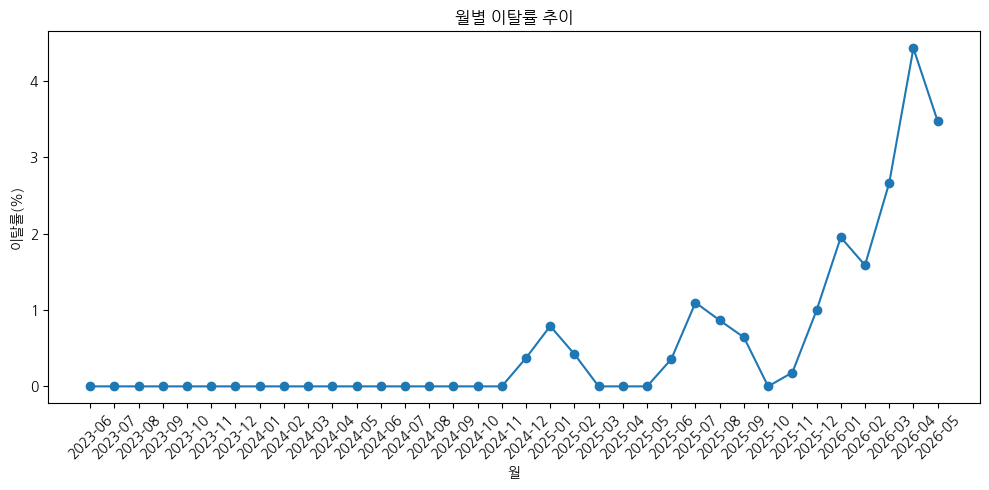

In [30]:
# 이 셀은 월별 이탈률 추이를 선 그래프로 시각화합니다.
monthly_churn_df = monthly_churn_df.sort_values(by='월')

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_churn_df['월'].astype(str),
    monthly_churn_df['월별이탈률'] * 100,
    marker='o'
)

plt.title(label='월별 이탈률 추이')
plt.xlabel(xlabel='월')
plt.ylabel(ylabel='이탈률(%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 10단계. 연령대와 가입 채널별 이탈률 교차표 계산

- 지시: df_churn에서 `연령대`와 `가입채널` 조합별 고객 수, 이탈 고객 수, 이탈률을 계산해 segment_churn_df를 생성하고 출력하세요.
- 이유: 어떤 연령대와 가입 채널 조합에서 이탈률이 높은지 비교하기 위함입니다.

In [31]:
# 이 셀은 연령대와 가입채널 조합별 고객 수, 이탈 고객 수, 이탈률을 계산합니다.
segment_churn_df = (
    df_churn.groupby(by=['연령대', '가입채널'])
    .agg(
        고객수=('고객ID', 'count'),
        이탈고객수=('이탈플래그', 'sum')
    )
    .reset_index()
)

segment_churn_df['이탈률'] = (
    segment_churn_df['이탈고객수']
    / segment_churn_df['고객수']
)

In [32]:
# 이 셀은 세그먼트별 이탈 현황 데이터프레임을 출력합니다.
segment_churn_df

,연령대,가입채널,고객수,이탈고객수,이탈률
0,10대,검색광고,35,7,0.200000
1,10대,소셜미디어,27,9,0.333333
2,10대,오프라인매장,12,1,0.083333
3,10대,제휴이벤트,26,10,0.384615
4,10대,지인추천,24,4,0.166667
5,20대,검색광고,77,13,0.168831
6,20대,소셜미디어,85,16,0.188235
7,20대,오프라인매장,55,14,0.254545
8,20대,제휴이벤트,71,29,0.408451
9,20대,지인추천,58,7,0.120690


### 11단계. 연령대와 가입 채널별 이탈률 시각화

- 지시: segment_churn_df를 사용해 `연령대`와 `가입채널`별 이탈률을 히트맵으로 시각화하세요.
- 이유: 교차분석 결과에서 고이탈 구간을 빠르게 식별하기 위함입니다.

In [33]:
# 이 셀은 히트맵 시각화에 필요한 라이브러리를 불러옵니다.
import seaborn as sns

In [34]:
# 이 셀은 히트맵에 사용할 피벗 테이블을 생성합니다.
segment_churn_pivot = segment_churn_df.pivot(
    index='연령대',
    columns='가입채널',
    values='이탈률'
)

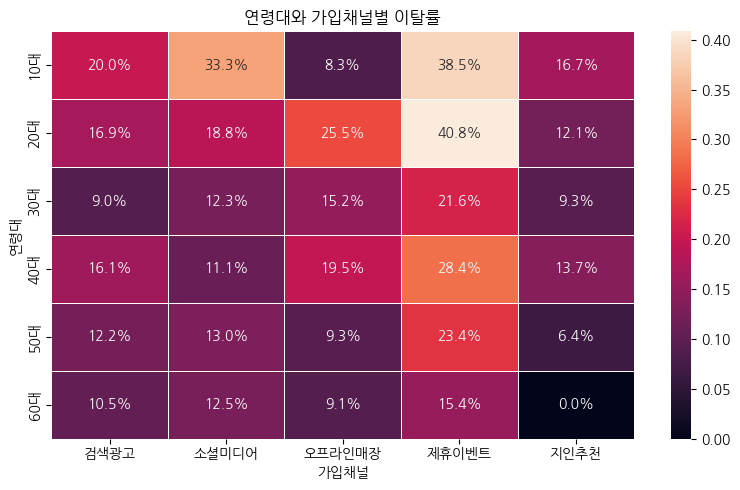

In [35]:
# 이 셀은 연령대와 가입채널별 이탈률을 히트맵으로 시각화합니다.
plt.figure(figsize=(8, 5))

sns.heatmap(
    data=segment_churn_pivot,
    annot=True,
    fmt='.1%',
    linewidths=0.5
)

plt.title(label='연령대와 가입채널별 이탈률')
plt.xlabel(xlabel='가입채널')
plt.ylabel(ylabel='연령대')

plt.tight_layout()
plt.show()

### 12단계. 이탈률 상위 집단 도출

- 지시: segment_churn_df에서 고객 수가 30명 이상인 조합을 대상으로 이탈률이 높은 상위 5개 집단을 top_churn_segments_df로 계산하고 출력하세요.
- 이유: 표본 수가 지나치게 작은 집단을 제외하고 신뢰할 수 있는 고이탈 집단을 찾기 위함입니다.

In [36]:
# 이 셀은 고객 수가 30명 이상인 조합 중 이탈률이 높은 상위 5개 집단을 계산합니다.
top_churn_segments_df = (
    segment_churn_df.loc[segment_churn_df['고객수'].ge(other=30)]
    .sort_values(by='이탈률', ascending=False)
    .head(n=5)
)

In [37]:
# 이 셀은 이탈률 상위 5개 집단을 출력합니다.
top_churn_segments_df

,연령대,가입채널,고객수,이탈고객수,이탈률
8,20대,제휴이벤트,71,29,0.408451
18,40대,제휴이벤트,116,33,0.284483
7,20대,오프라인매장,55,14,0.254545
23,50대,제휴이벤트,47,11,0.234043
13,30대,제휴이벤트,102,22,0.215686


### 13단계. 최고 이탈 집단의 특징 비교

- 지시: df_churn에서 top_churn_segments_df의 1위 집단과 나머지 고객을 구분하는 `고이탈집단여부` 변수를 만들고, 두 집단의 `요금제`, `성별` 분포와 `가입경과월`, `최근30일_로그인수`, `월평균사용시간`, `고객센터문의수`, `최근3개월_결제실패` 평균을 각각 별도의 셀에서 출력하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 이탈률이 가장 높은 집단이 다른 고객과 어떤 행동 및 속성 차이를 보이는지 확인하기 위함입니다.

In [38]:
# 이 셀은 top_churn_segments_df의 1위 집단 조건을 추출합니다.
top_segment = top_churn_segments_df.iloc[0]

top_age_group = top_segment['연령대']
top_channel = top_segment['가입채널']

In [39]:
# 이 셀은 1위 집단과 나머지 고객을 구분하는 고이탈집단여부 변수를 생성합니다.
df_churn['고이탈집단여부'] = (
    df_churn['연령대'].eq(other=top_age_group)
    & df_churn['가입채널'].eq(other=top_channel)
)

In [40]:
# 이 셀은 두 집단의 요금제 분포를 확인합니다.
pd.crosstab(
    index=df_churn['고이탈집단여부'],
    columns=df_churn['요금제'],
    normalize='index'
)

요금제,베이직,스탠다드,프리미엄
고이탈집단여부,,,
False,0.448937,0.353551,0.197512
True,0.507042,0.323944,0.169014


In [41]:
# 이 셀은 두 집단의 성별 분포를 확인합니다.
pd.crosstab(
    index=df_churn['고이탈집단여부'],
    columns=df_churn['성별'],
    normalize='index'
)

성별,남,여
고이탈집단여부,,
False,0.505443,0.494557
True,0.464789,0.535211


In [42]:
# 이 셀은 두 집단의 주요 수치형 변수 평균을 확인합니다.
mean_cols = [
    '가입경과월',
    '최근30일_로그인수',
    '월평균사용시간',
    '고객센터문의수',
    '최근3개월_결제실패'
]

df_churn.groupby(by='고이탈집단여부')[mean_cols].mean()

,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패
고이탈집단여부,,,,,
False,18.254536,10.635044,18.322136,0.635562,0.292898
True,19.619718,8.436620,14.353521,0.676056,0.436620


### 14단계. 분석 결과 파일 저장

- 지시: monthly_churn_df, segment_churn_df, top_churn_segments_df를 각각 CSV 파일로 저장하세요.
- 이유: 월별 이탈률과 교차분석 결과를 보고서나 대시보드 작성에 재사용하기 위함입니다.

In [ ]:
# 위 '지시'를 Python Code Assistant에 입력해 받은 코드를 여기에 붙여넣고 실행하세요.